In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\HONER\Downloads\archive (2)\heart.csv")
df.head(50)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## 1. Train a Decision Tree Classifier and visualize the tree

In [6]:
x = df.iloc[:,:-1]
y = df["target"]

In [7]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [8]:
from sklearn.tree import DecisionTreeRegressor,plot_tree

In [9]:
dt = DecisionTreeRegressor(max_depth = 10)
dt.fit(x_train,y_train)

DecisionTreeRegressor(max_depth=10)

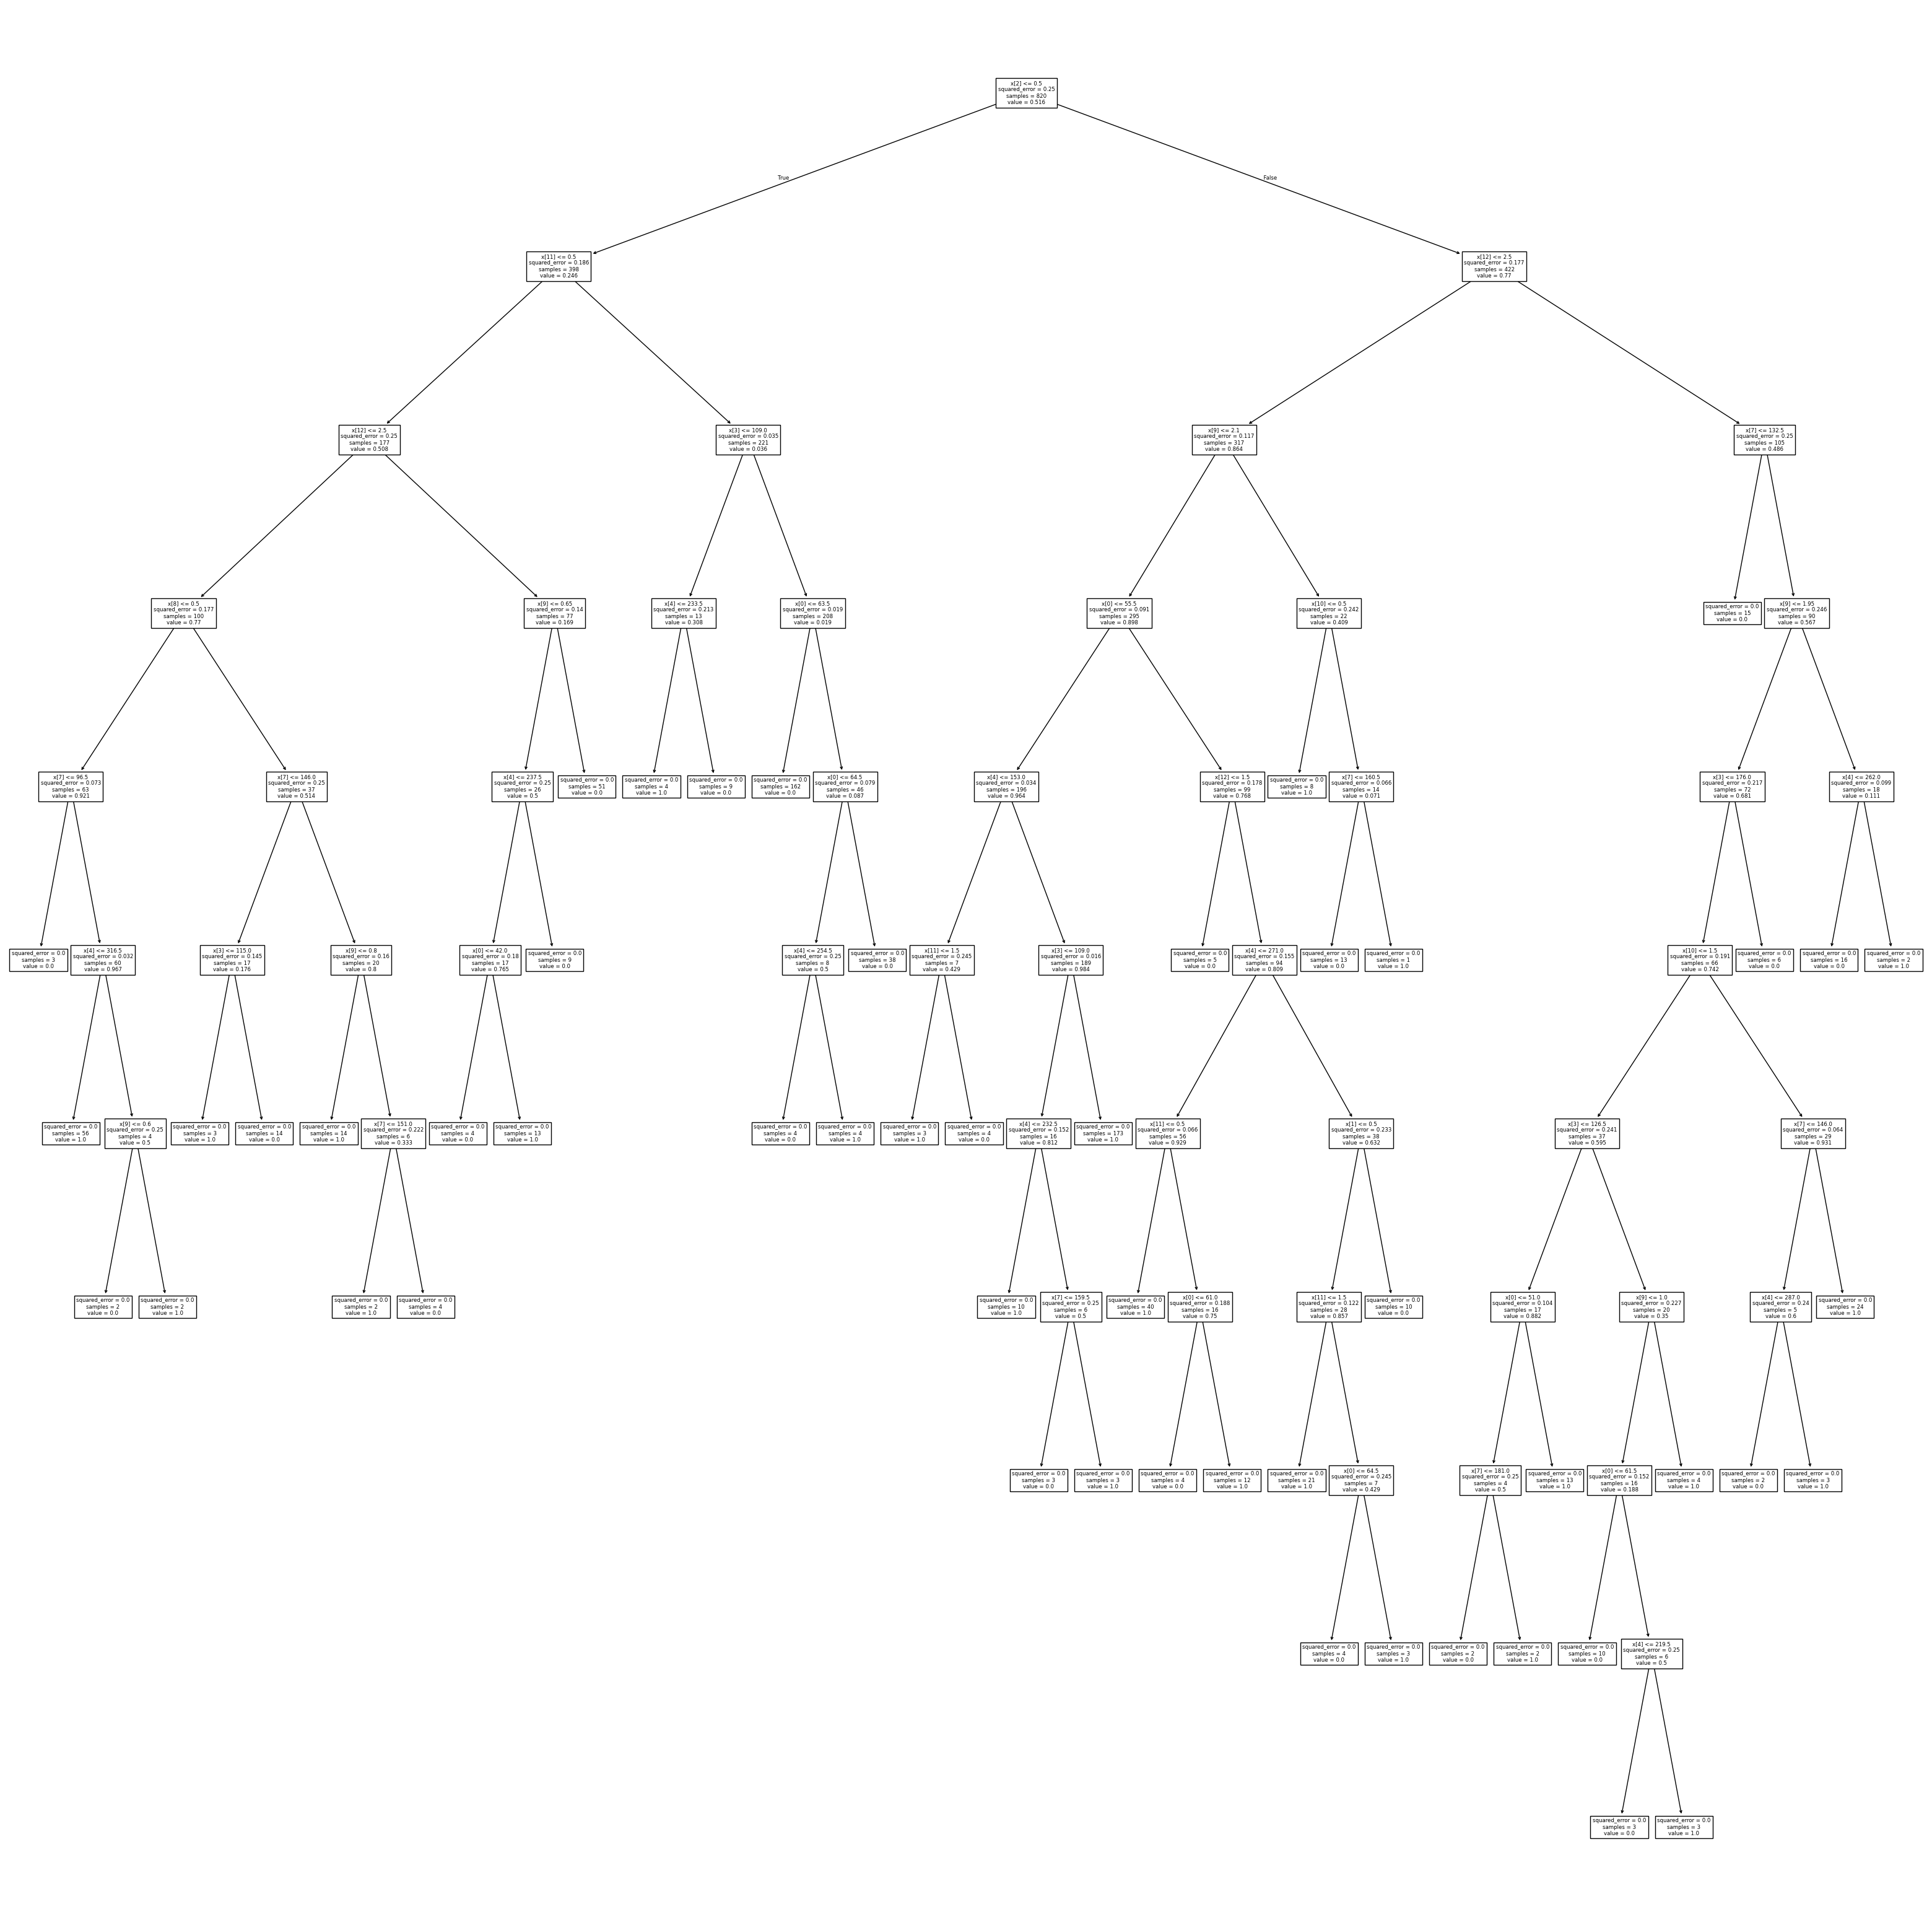

In [10]:
plt.figure(figsize = (40,40))
plot_tree(dt)
plt.show()

In [11]:
test = dt.score(x_test,y_test)*100
test

94.14620217018846

In [12]:
train = dt.score(x_train,y_train)*100

## 2. Analyze overfitting and control tree depth

In [13]:
Overfitting = train - test

In [14]:
Overfitting

5.8537978298115405

* When we increasing max_depth size of DecisionTreePlot then the accuracy is going to increasing.

## 3. Train a Random Forest and compare accuracy

In [15]:
from sklearn.ensemble import RandomForestClassifier

In [16]:
rf = RandomForestClassifier()

In [17]:
rf.fit(x_train,y_train)

RandomForestClassifier()

In [18]:
rf.score(x_test,y_test)*100

98.53658536585365

* Compare Accuracy :-
 After the Implementation of RandomForestClassifier the accuracy of model is icrease (94.14620217018846 to 98.53658536585365).

## 4. Interpret feature importances

* In heart disease prediction, the importance of features like age, sex, and oldpeak can vary depending on the model used. Here's a general ranking based on common studies:
- Oldpeak (ST depression induced by exercise) – Highly significant. It reflects ischemia (lack of blood flow), making it a strong predictor of heart disease.
- Age – Important. Older individuals are at higher risk due to factors like arterial stiffness and accumulated health conditions.
- Sex – Moderately important. Men generally have a higher risk of heart disease compared to premenopausal women, but postmenopausal women see an increased risk.

Would you like help applying feature importance techniques to a specific dataset? I can guide you through it!


## Evaluate using cross-validation.

In [19]:
from sklearn.model_selection import cross_val_score,KFold

In [20]:
cv = cross_val_score(DecisionTreeRegressor(),x,y,cv =KFold(n_splits = 10 ))

In [21]:
cv.sort()
cv*100

array([100., 100., 100., 100., 100., 100., 100., 100., 100., 100.])

In [24]:
dt.predict([[50,1,2,129,196,0,1,163,0,0.0,2,0,2]])

C:\Users\HONER\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([1.])